# Making An Entangled State

In [61]:
# !pip install qiskit
# !pip install pylatexenc
# !pip install qiskit_aer

In [62]:
# Import necessary libraries
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_qsphere, plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import Aer  # For simulating the circuit.

# Making The Entangling Circuit

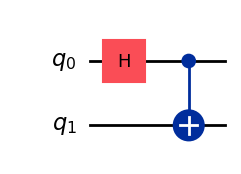

In [63]:
entgl_circt = QuantumCircuit(2)
entgl_circt.h(0)
entgl_circt.cx(0, 1) # '(0, 1)' the '0' is control qubit and '1' is target qubit
entgl_circt.draw("mpl")

# Evolving The State, |10>

Representing On Qsphere

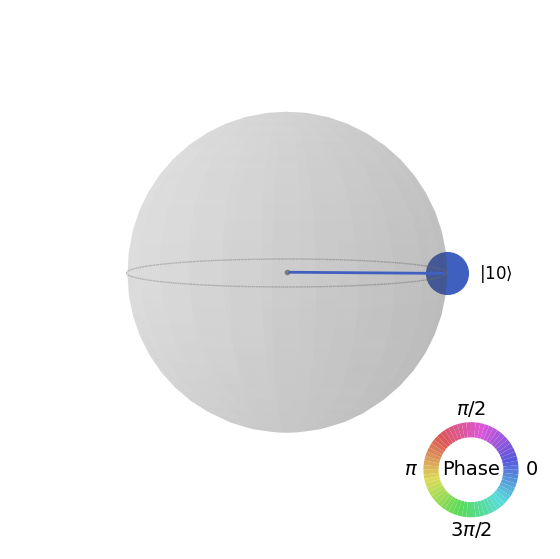

In [64]:
sv_10 = Statevector.from_label("10") # It reads qubit from right to left, i.e., q_0 (control) = |0> and q_1 (target) = |1>, which means the writing convention is |q_1q_0>
plot_state_qsphere(sv_10.data) # The size of the dot shows the amplitude of the state and color shows the phase.

Representing On Bloch Sphere


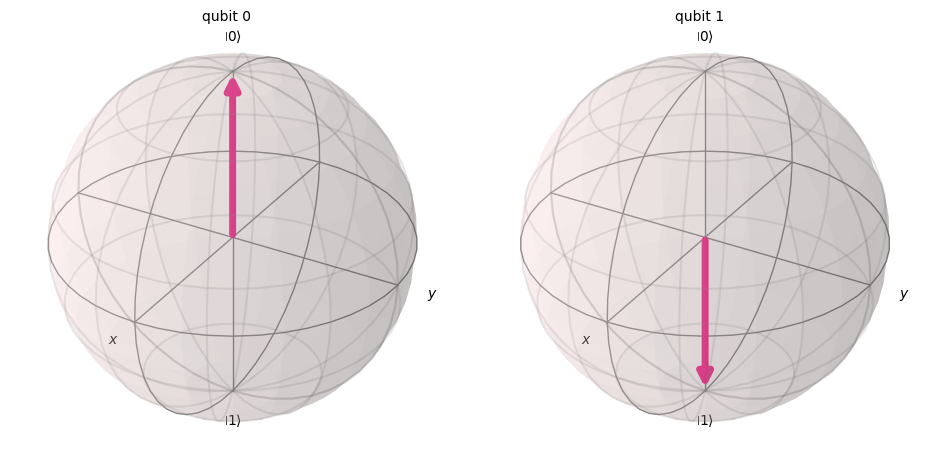

In [65]:
plot_bloch_multivector(sv_10)

Entangling The State

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


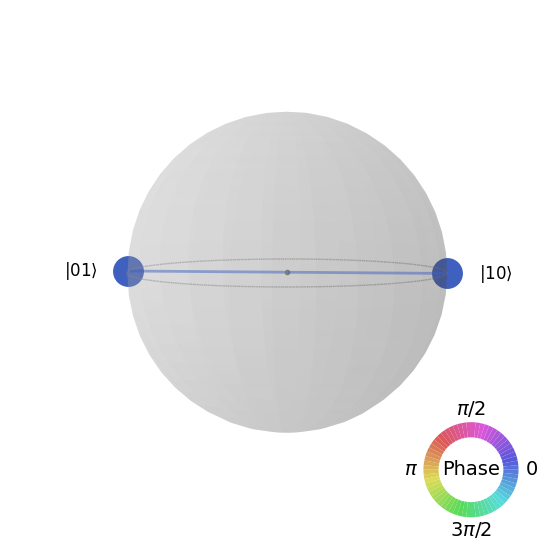

In [66]:
entgl_sv_10 = sv_10.evolve(entgl_circt)
print(entgl_sv_10)
# plot_bloch_multivector(entgl_sv_10) # As the state is now entangled it cannot be represented on Bloch sphere
plot_state_qsphere(entgl_sv_10.data)

# Evolving The State, |11>

Representing On Qsphere

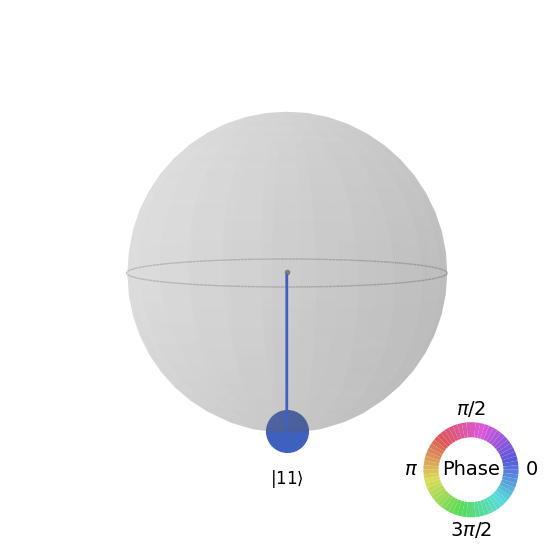

In [67]:
sv_11 = Statevector.from_label("11")
plot_state_qsphere(sv_11.data)

Representing On The Bloch Sphere

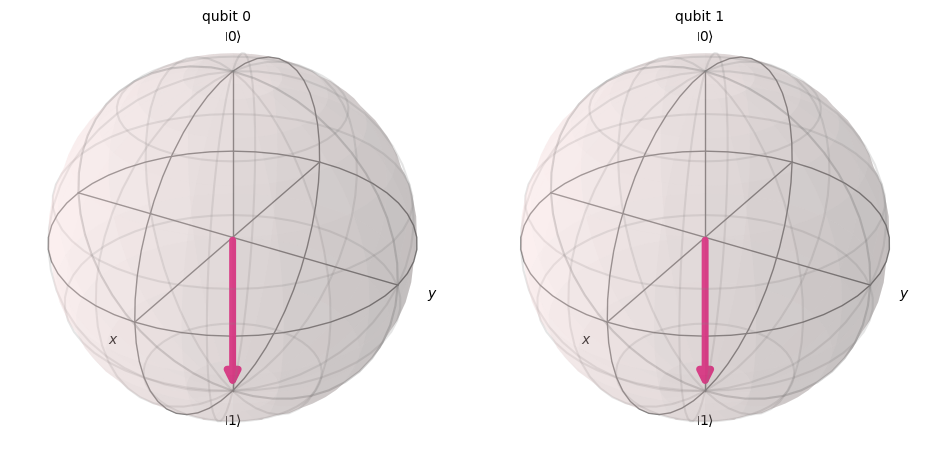

In [68]:
plot_bloch_multivector(sv_11)

Entangling The State

Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


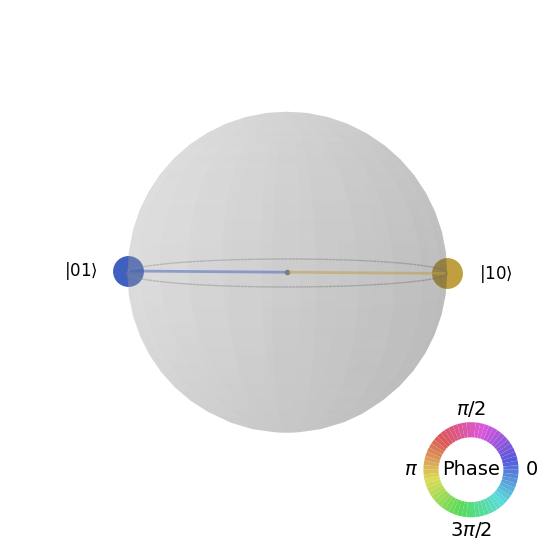

In [69]:
entgl_sv_11 = sv_11.evolve(entgl_circt)
print(entgl_sv_11)
plot_state_qsphere(entgl_sv_11.data)

# Measurement state |00> On Simulator


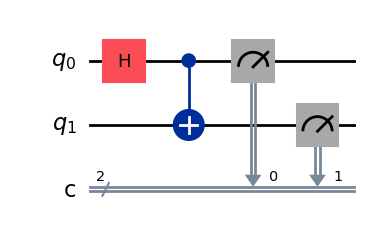

In [70]:
entgl_circt_00 = QuantumCircuit(2, 2) # 2 qubits and 2 classical bits
entgl_circt_00.h(0)
entgl_circt_00.cx(0, 1)
entgl_circt_00.measure(0, 0)
entgl_circt_00.measure(1, 1)
entgl_circt_00.draw("mpl")

Simulating The Circuit

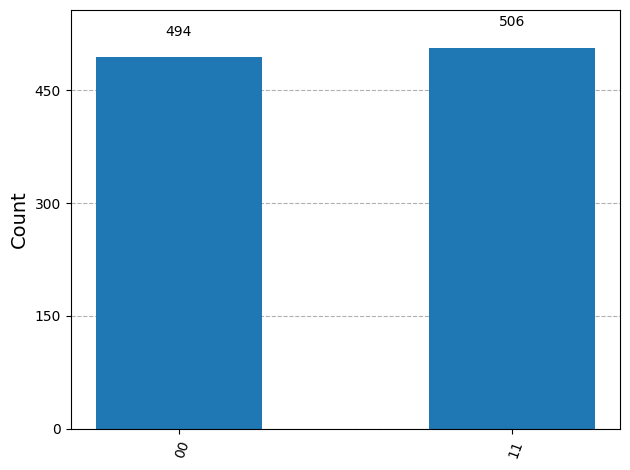

In [71]:
simulator_00 = Aer.get_backend("qasm_simulator")
result = simulator_00.run(entgl_circt_00, shots = 1000).result()
counts = result.get_counts()
plot_histogram(counts)

# Measuring State |01> On Simulator

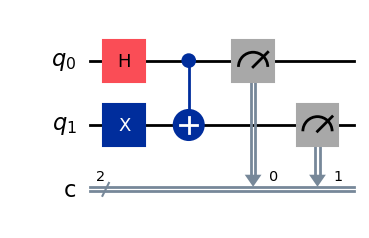

In [72]:
entgl_circt_01 = QuantumCircuit(2, 2)
entgl_circt_01.x(1)
entgl_circt_01.h(0)
entgl_circt_01.cx(0, 1)
entgl_circt_01.measure(0, 0)
entgl_circt_01.measure(1, 1)
entgl_circt_01.draw("mpl")

Simulating The Circuit


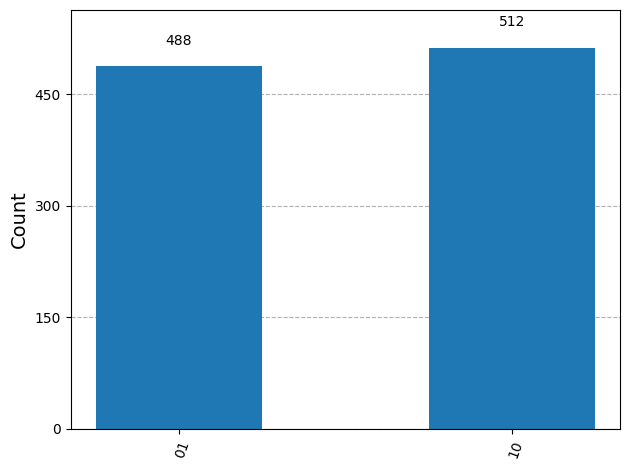

In [73]:
simulator_01 = Aer.get_backend("qasm_simulator")
result = simulator_01.run(entgl_circt_01, shots = 1000).result()
counts = result.get_counts()
plot_histogram(counts)

# Example On The Phase Kick Back Effect

Phase Kick Back Explanations,

1, (https://chatgpt.com/s/t_6a2d57b8e8048191b5cb2d3151aec1fa)


2, (https://chatgpt.com/s/t_6a2d5b029f4c8191900394676f497f70)

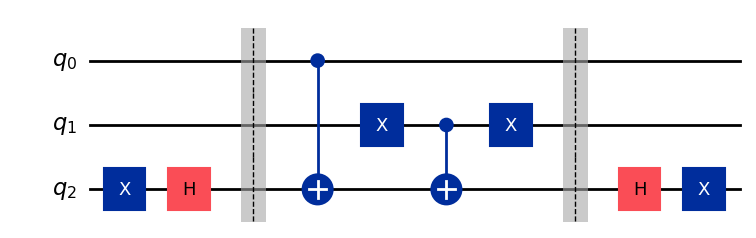

In [74]:
n = 2 # Target quibit
phase_kb = QuantumCircuit(n + 1)

# Converting the target qubit 'n' to |->, because the target qubit should be the eigen state of the controlled U-gate, i.e., X|-> = -|->.
phase_kb.x(n)
phase_kb.h(n)
phase_kb.barrier()
phase_kb.cx(0, n)
phase_kb.x(1)
phase_kb.cx(1, n)
phase_kb.x(1)
phase_kb.barrier()
phase_kb.h(n)
phase_kb.x(n)
phase_kb.draw("mpl")

On State |010>

In [75]:
sv_010 = Statevector.from_label("010")
print(sv_010)
sv_010_evlv = sv_010.evolve(phase_kb)
print(sv_010_evlv)


Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))
Statevector([ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  1.00000000e+00+0.j,
              0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
             -2.23711432e-17+0.j,  0.00000000e+00+0.j],
            dims=(2, 2, 2))


On State |011>

In [76]:
sv_011 = Statevector.from_label("011")
print(sv_011)
sv_011_evlv = sv_011.evolve(phase_kb)
print(sv_011_evlv)

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))
Statevector([ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
             -1.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              0.00000000e+00+0.j,  2.23711432e-17+0.j],
            dims=(2, 2, 2))


Hence, this phase kick back effect shows, we have half the probability to get the phase flipped, means,

Suppose we start with superposition,

(|010> + |011>)/√2


From above,

|010> --> |010> (1/2 probability of phase not flipped.)

and

|011> --> -|011> (1/2 probability of phase gets flipped.)


Therefore,

(|010> + |011>)/√2 --> (|010> - |011>)/√2


Now the relative phase changed.

That relative phase can later interfere and alter measurement probabilities.

That is the whole purpose of phase kickback.